# R-KV Token Dropping with the LMCache SDK
---

Long prompts create large KV caches. They eat GPU memory, limit how many requests
fit in a batch, and a smaller batch means lower decode throughput. *Token
dropping* shrinks each request's KV cache — by half in this notebook — so more
requests fit and decoding runs faster.

This notebook uses the LMCache SDK to pull a request's KV cache out after
prefill, compress it, and put it back before decode. The compression algorithm
is **R-KV**.

## R-KV vs. SnapKV, and why it needs optimizing

SnapKV ranks past tokens by **attention importance** alone: how much the last
`w` prompt tokens attend to them. R-KV keeps that term but subtracts a second
one, **redundancy** — how similar a token's key is to the *other* keys:

$$\text{score}(j) \;=\; \lambda \cdot \underbrace{\text{importance}(j)}_{\text{attended to?}} \;-\; (1-\lambda) \cdot \underbrace{\text{redundancy}(j)}_{\text{says something new?}}$$

Keeping tokens that are both attended-to **and** non-redundant works especially
well on the repetitive output of reasoning models.

The catch is arithmetic. Per layer, for a prompt of $n$ tokens with head
dimension $d$:

| term | cost |
|---|---|
| SnapKV importance (window $w = 64$) | $O(w \cdot n \cdot d)$ |
| R-KV redundancy (**all pairs of keys**) | $O(n^2 \cdot d)$ |

The ratio is $n / w$. At $n = 16128$ that is **~250× more arithmetic per layer
than SnapKV**, and a literal implementation also materializes an $n \times n$
matrix per layer. A direct port of the reference code needed **over an hour** for
the 30 prompts below. Making R-KV practical is what the rest of this notebook is
about.

## Four implementations

All four produce R-KV scores; they differ in *how* the redundancy term is
evaluated and *where* it runs. Implementations 1–3 are **exact** — they select
the same tokens, asserted by their self-tests. Implementation 4 trades some of
that for speed.

1. **Route A, one-shot, on the GPU** — the literal all-pairs formulation, made
   survivable by tiling the $n \times n$ matrix and capping how many requests
   touch the GPU at once. Still $O(n^2 d)$, so it needs ~10 GiB of VRAM.

2. **Route A, exact and linear, on the CPU** — the same result, but the column
   sums R-KV actually needs are rewritten as a single inner product, dropping
   the cost to $O(n \cdot d)$ plus a short scan. No approximation, and no GPU.

3. **Route A, exact and linear, on the GPU** — the linear formulation with row
   tiling, so the footprint becomes a knob instead of a function of prompt
   length: the fastest exact option, in **~1.55 GiB** of VRAM.

4. **Route B, buffered / chunked, on the CPU** — the approach the R-KV serving
   ports take: compare keys only inside a chunk, making the similarity matrix
   block-diagonal. The quickest CPU option, at ~96% agreement with the exact
   token set.

All four keep the same 50% of the tokens, so they deliver the **same decode
speed-up** — measured 1740–1801 tok/s across two full runs, a spread that is
within run-to-run noise. What actually separates them is the **cost of
compressing**: ~27 s, ~33 s, ~41 s and ~66 s for the same 30 requests.

Requirements:
* A small ~10-line modification to vLLM exposes intermediate tensors to LMCache.
  See [README.md](./README.md).

* A GPU is required for serving. To see token dropping increase the decode batch

  size, tune the GPU memory utilization together with the number of requests.  is unavailable the SDK falls back to pickle.
* Data moves between the LMCache server and the SDK through shared memory; if it

## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 400 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy \
    --enable transfer_query
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
LMCACHE_TRANSFER_INTERMEDIATE_TENSORS=true \
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once
from utils import (
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)


[2026-07-25 07:36:24,684] LMCache INFO: torch_dev=<module 'torch.cuda' from '/home/sigma/github/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:249:lmcache.v1.platform)
[2026-07-25 07:36:24,784] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:239:lmcache.v1.platform)
[2026-07-25 07:36:24,859] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.3.dev28 (g60216f31)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [2]:
model_name = "/data/models/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

# Streams prefilled per submission. LMCache's query ring buffer maps a forward
# step's query rows to ring slots positionally (qringbuffer.py
# build_q_step_state), assuming each request contributed exactly its store op's
# token count of rows. Continuous batching breaks that, so the captured queries
# are silently wrong or short. Measured query-row reproducibility across two
# identical runs: 100.0% at 1 stream, 99.7% at 4, 9.8% at 30. R-KV's importance
# term is entirely query-driven, so prefill is submitted one stream at a time.
prefill_group_size = 1


## Configuring the model and LMCache endpoint

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)


[2026-07-25 07:36:46,119] LMCache INFO: Initialized LMCacheSDKContext with instance_id=4026529288294415499, model_name=/data/models/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:159:lmcache.sdk.context)
[2026-07-25 07:36:46,122] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:769:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-25 07:36:46,320] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:100:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-25 07:36:46,323] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:44:lmcache.v1.gpu_connector.kv_format.detection)
[2026-07-25 07:36:46,324] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=429496729600) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-07-

## Constructing Prompt

In [4]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Loaded 30 prompts from the dataset.
Total prompts length: 423428 tokens.
Mean prompt length: 14114.27 tokens.
Max prompt length: 16807 tokens.
Min prompt length: 10159 tokens.


## Baseline (without token dropping)


In [5]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.stream.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
before_drop_data = results.to_dict()
before_texts = [stream.output_text for stream in batch.streams.values()]


[2026-07-25 07:39:38,657] LMCache INFO: prefill: 15.15 s in groups of 1 (2762004177.py:24:__main__)


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       173.22
Total Output Tokens:                                                      153483
Decode Throughput (tokens/s):                                             886.07


## Clear LMCache


In [6]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

## With R-KV Token Dropping

Three implementations follow, all producing the same R-KV scores and differing
only in *how* the redundancy term is evaluated and *where* it runs. This cell
holds the hyperparameters and the tensor plumbing they share.


In [7]:
# Standard
import contextlib
import os
import threading

# --- R-KV hyperparameters ----------------------------------------------------
# Scores are averaged over KV heads and summed over layers, so a request keeps
# ONE token subset. LMCache re-injects a single contiguous KV with a single
# kept-token list, so per-head eviction is not expressible here.
rkv_window_size = 8  # observation window: the last w queries vote on importance
rkv_drop_ratio = 0.5  # fraction of tokens to evict
rkv_kernel_size = 7  # max-pool width applied to the importance scores
rkv_mix_lambda = 0.07  # score = lambda * importance - (1 - lambda) * redundancy
rkv_sim_threshold = 0.5  # cosine above this counts as "similar"

# --- CPU thread budget (shared by both CPU implementations) ------------------
cpu_thread_oversubscription = 1.25  # total intra-op threads / usable cores
cpu_reserve_cores = 4  # left for vLLM, the LMCache server and the OS
cpu_device = torch.device("cpu")


def usable_cores():
    """Cores this process may actually run on -- affinity and cgroup, not nproc."""
    try:
        cores = len(os.sched_getaffinity(0))
    except AttributeError:
        cores = os.cpu_count() or 1
    try:
        with open("/sys/fs/cgroup/cpu.max") as fh:
            quota, period = fh.read().split()
        if quota != "max":
            cores = min(cores, max(1, int(int(quota) // int(period))))
    except (OSError, ValueError):
        pass
    return max(1, cores)


def plan_cpu_threads():
    """Set torch's intra-op threads so intra_op * workers ~= 1.25 * cores.

    `batch.modify` runs one worker thread per stream and torch defaults to one
    intra-op thread per core inside each of them, which on a 96-core box means
    30 x 96 = 2880 runnable threads. Measured over 30 requests: 27.6 s at 96
    intra-op threads, 19.8 s at 4, 33.5 s at 1.
    """
    cores = usable_cores()
    budget = max(1, round((cores - cpu_reserve_cores) * cpu_thread_oversubscription))
    workers = max(1, len(prompts))
    intra_op = max(1, min(budget // workers, budget))
    torch.set_num_threads(intra_op)
    logger.info(
        f"CPU thread plan: {cores} usable cores -> budget {budget}, "
        f"{workers} workers -> torch.set_num_threads({intra_op}) "
        f"(~{intra_op * workers} runnable threads)"
    )
    return intra_op


cpu_intraop_threads = plan_cpu_threads()


# --- Tensor plumbing ---------------------------------------------------------
def model_heads():
    """(num_q_heads, num_kv_heads, head_dim) for the served model."""
    q = config.num_attention_heads
    kv = getattr(config, "num_key_value_heads", q)
    return q, kv, getattr(config, "head_dim", config.hidden_size // q)


def to_heads(flat, rows, heads, head_dim, device=None):
    """[rows, heads * head_dim] -> [1, heads, rows, head_dim] in fp32."""
    t = flat.to(dtype=torch.float32) if device is None else flat.to(device, torch.float32)
    return t.reshape(rows, heads, head_dim).permute(1, 0, 2).unsqueeze(0)


def q_by_layer(q_tensor):
    """Normalise the SDK's query tensor to [num_layers, T, q_heads * head_dim]."""
    if q_tensor.ndim == 4 and q_tensor.shape[0] == 1:
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"unexpected q_tensor shape {tuple(q_tensor.shape)}")


def attention_logits(query, key, pooling="max"):
    """q @ k^T / sqrt(d), pooled from query heads down to KV heads (GQA).

    query: [1, q_heads, q_len, d]   key: [1, kv_heads, kv_len, d]
    """
    _, q_heads, q_len, d = query.shape
    kv_heads = key.shape[1]
    group = q_heads // kv_heads
    if group == 1:
        return torch.matmul(query, key.transpose(2, 3)) / math.sqrt(d)
    q = query.view(1, kv_heads, group, q_len, d)
    attn = torch.matmul(q, key.unsqueeze(2).transpose(3, 4)) / math.sqrt(d)
    return attn.mean(dim=2) if pooling == "mean" else attn.max(dim=2).values


def importance(k, q_win, past_len):
    """How much the observation window attends to each past token.

    Only the window queries are passed in, so this is O(w * n * d) rather than
    the O(n^2 * d) the reference spends before discarding all but the last w rows.
    """
    attn = attention_logits(q_win, k)[:, :, :, :past_len]
    scores = F.softmax(attn, dim=-1, dtype=torch.float32).mean(dim=-2)
    return F.max_pool1d(
        scores, kernel_size=rkv_kernel_size, padding=rkv_kernel_size // 2, stride=1
    )


def redundancy_reference(key_states, threshold=rkv_sim_threshold):
    """Literal R-KV redundancy: materialises the whole n x n matrix.

    Only used as the correctness oracle in the self-tests -- never on a real
    prompt, where it would allocate kv_heads * n^2 floats per layer.
    """
    _, _, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    sim = torch.matmul(k, k.transpose(-1, -2))
    eye = torch.eye(n, dtype=torch.bool, device=k.device).view(1, 1, n, n)
    sim.masked_fill_(eye, 0.0)

    # Per row, exempt the LARGEST column index that is above threshold (or
    # column 0 if none qualifies) -- R-KV's `similarity_retain` rule.
    mask = sim > threshold
    idx = torch.arange(n, device=k.device).view(1, 1, 1, n)
    retain = torch.where(mask, idx, torch.zeros_like(mask, dtype=torch.long))
    sim.scatter_(-1, retain.max(dim=-1)[0].unsqueeze(-1), 0)
    return sim.mean(dim=-2).softmax(dim=-1)


def prepare(tensors, token_source):
    """Common bookkeeping shared by every drop_tokens_fn."""
    kv = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]  # [2, L, T, D]
    q = q_by_layer(tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY])
    seq_len = min(kv.shape[2], q.shape[1], len(token_source))
    past_len = seq_len - rkv_window_size
    if past_len <= 0:
        raise ValueError(f"seq_len {seq_len} must exceed window {rkv_window_size}")
    keep_total = int(round(seq_len * (1 - rkv_drop_ratio)))
    keep_past = max(0, min(keep_total - rkv_window_size, past_len))
    q_win = q[:, past_len:seq_len, :]  # window only: ~2.4 MiB, not ~4.8 GiB
    return kv, q_win, seq_len, past_len, keep_past


def select(scores, past_len, seq_len, keep_past):
    """Top-scoring past tokens plus the whole observation window."""
    top = torch.topk(scores, k=keep_past).indices.sort().values
    tail = torch.arange(past_len, seq_len, device=scores.device)
    return torch.cat([top, tail]).to(torch.long).cpu()


def rerotate(kv_tensor, keep_idx, device):
    """Gather the kept tokens and move their RoPE to the new positions."""
    gathered = kv_tensor[:, :, keep_idx, :].clone().to(device)
    out = rerotate_k_cache(
        gathered,
        old_positions=keep_idx.to(device),
        new_positions=torch.arange(keep_idx.numel(), device=device),
        model_config=config,
    )
    return out.cpu()


[2026-07-25 07:42:45,323] LMCache INFO: CPU thread plan: 96 usable cores -> budget 115, 30 workers -> torch.set_num_threads(3) (~90 runnable threads) (2337664241.py:51:__main__)


### Implementation 1 — Route A, one-shot, on the GPU

> **Trades VRAM and scaling for simplicity.** It is R-KV written the way the
> paper describes it, so it is the easiest to read and to check against the
> reference — but it pays $O(n^2)$ in both time and memory.
>
> | | |
> |---|---|
> | **Buys you** | The simplest, most literal code; easy to verify against the reference implementation |
> | **Costs you** | ~9.8 GiB of VRAM, and cost grows **quadratically** with prompt length |
> | Exact? | Yes |
> | VRAM | ~9.8 GiB (concurrency cap 4) |
> | Compress 30 requests | ~41–48 s |
> | Decode throughput | ~1795–1798 tok/s |
> | Pick it when | You want the reference formulation, prompts are short, and VRAM is plentiful |

**Route A** is R-KV as written: every past token is scored against the *whole*
prompt, so the redundancy term is the full $n \times n$ cosine matrix. This
implementation keeps that formulation and simply makes it survivable.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Window-only queries.** The reference builds a full `[kv_heads, n, n]` logit tensor and then throws away everything except the last `w` rows. Slicing the queries *before* the matmul computes only the rows that survive. | $n / w \approx 2000\times$ fewer FLOPs on the importance term, and the host→device copy of Q drops from ~4.8 GiB to ~2.4 MiB per request. |
| 2 | **Tiled column sums.** R-KV reduces the similarity matrix with a mean over rows, so only a per-column accumulator has to survive. Rows are processed `row_block` at a time. The per-row "retain" index is read straight off the boolean mask with `flip(-1).argmax(-1)`. | The reference's `torch.where(mask, arange, 0)` idiom allocates **two int64 `[kv_heads, n, n]` tensors** — 16.6 GiB each at $n=16128$ — on top of the fp32 matrix. Removing them turned a DRAM-bound pass into a compute-bound one. |
| 3 | **Per-layer key staging.** Keys are copied to the device one layer at a time. | Staging all 36 layers up front is a 1.19 GiB *resident* allocation per in-flight request that no tile size can shrink. |
| 4 | **Concurrency cap.** A semaphore bounds how many requests are inside the GPU section at once. | See below — this is the one that decides whether the run survives at all. |

## GPU footprint and how the concurrency cap is derived

The trap is that `batch.modify` submits **one worker thread per stream**
(`ThreadPoolExecutor(max_workers=len(stream_ids))`), so all 30 requests execute
the compression function *simultaneously in one CUDA context*. A single-request
measurement therefore understates the real peak by 30×.

Per-request footprint is estimated from tensor shapes, as the larger of the two
phases (they never overlap inside a thread):

$$
\text{scoring} = \underbrace{n \cdot D \cdot 10}_{\text{staged + fp32 + normalised}} + \underbrace{H \cdot \text{row\_block} \cdot n \cdot 7}_{\text{fp32 tile + masks}}
\qquad
\text{rerotate} = 2 L \cdot \text{keep} \cdot D \cdot 2 \;+\; \text{RoPE temporaries}
$$

At $n = 16807$, keep 50%: scoring 1.06 GiB vs rerotate **1.28 GiB** — the
rerotate gather binds, which is why lowering `row_block` would *not* help here.
Total peak was then fitted against a measured 30-thread sweep and rounded up:

$$\text{peak}(\text{cap}) \approx \text{per\_request} \times (1.4 \cdot \text{cap} + 3.0)$$

| cap | measured peak |
|---|---|
| 2 | 6.47 GiB |
| 4 | 9.80 GiB |
| 8 | 16.25 GiB |

Inverting it gives the cap from the free VRAM reported by
`torch.cuda.mem_get_info` — which is device-wide, so vLLM's pool and the LMCache
server's own CUDA context are already subtracted — minus a reserve for what
grows *after* the snapshot (vLLM activations during decode, allocator
fragmentation). If not even one request fits, scoring falls back to the CPU
instead of crashing.

Wall-clock was flat at 42.9 / 42.2 / 41.5 s for cap 2 / 4 / 8, so the cap costs
no throughput: the slow part of `modify` is waiting on LMCache, which happens
before the gate and stays fully concurrent.

**Result: ~9.8 GiB of VRAM, ~41–48 s to compress 30 requests.**


In [8]:
# --- Knobs -------------------------------------------------------------------
oneshot_device = "cuda:0"  # a request only; downgraded to CPU if VRAM is short
oneshot_row_block = 1024  # rows scored per tile
oneshot_vram_reserve_gib = 8.0  # held back for what grows after the snapshot
oneshot_cap_limit = 4  # ceiling on the auto-sized concurrency cap
oneshot_allow_tf32 = True  # kept-token set was bit-identical to strict fp32

# peak(cap) ~= per_request * (GROWTH * cap + BASE), fitted above the measured
# 30-thread sweep (6.47 / 9.80 / 16.25 GiB at cap 2 / 4 / 8) so sizing errs small.
_PEAK_GROWTH, _PEAK_BASE = 1.4, 3.0


def _oneshot_redundancy(key_states, row_block):
    """Route A redundancy, tiled over rows.

    Same values as `redundancy_reference` but peak memory is
    O(kv_heads * row_block * n) instead of O(kv_heads * n^2), and no int64
    temporaries are built.
    """
    bsz, kv_heads, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    col_sum = torch.zeros((bsz, kv_heads, n), dtype=torch.float32, device=k.device)

    for r0 in range(0, n, row_block):
        r1 = min(r0 + row_block, n)
        sim = torch.matmul(k[:, :, r0:r1, :], k.transpose(-1, -2))
        local = torch.arange(r1 - r0, device=k.device)
        sim[:, :, local, r0 + local] = 0.0  # a token is not redundant with itself

        # `similarity_retain`: the largest above-threshold column per row, read
        # as "first True scanning from the right"; column 0 when none qualifies.
        over = sim > rkv_sim_threshold
        hit = over.any(dim=-1)
        last = (n - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
        retain = torch.where(hit, last, torch.zeros_like(last))
        sim.scatter_(-1, retain.unsqueeze(-1), 0.0)

        col_sum += sim.sum(dim=-2)
        del sim, over, hit, last, retain

    return (col_sum / n).softmax(dim=-1)


def _oneshot_estimate(seq_len, num_layers, kv_heads, head_dim, row_block):
    """Per-request device bytes: (peak, scoring, rerotate)."""
    kvd = kv_heads * head_dim
    scoring = seq_len * kvd * 10 + kv_heads * min(row_block, seq_len) * seq_len * 7
    keep = int(round(seq_len * (1 - rkv_drop_ratio)))
    rerotate_b = 2 * num_layers * keep * kvd * 2 + 8 * keep * kvd * 2
    return max(scoring, rerotate_b), scoring, rerotate_b


def _oneshot_plan(spec):
    """Pick the device and size the concurrency cap from free VRAM."""
    dev = torch.device(spec)
    if dev.type != "cuda" or not torch.cuda.is_available():
        logger.info("Route A one-shot: running on the CPU, no cap needed.")
        return torch.device("cpu"), 0

    seq_len = max(len(p) for p in prompts)  # size against the worst case
    _, kv_heads, head_dim = model_heads()
    per_req, scoring, rerotate_b = _oneshot_estimate(
        seq_len, int(config.num_hidden_layers), kv_heads, head_dim, oneshot_row_block
    )
    binding = "scoring tile" if scoring >= rerotate_b else "rerotate gather"

    free_b, total_b = torch.cuda.mem_get_info(dev)
    usable = free_b - int(oneshot_vram_reserve_gib * 2**30)
    cap = int((usable / per_req - _PEAK_BASE) / _PEAK_GROWTH) if usable > 0 else 0
    cap = max(0, min(cap, oneshot_cap_limit))

    logger.info(
        f"Route A one-shot on {dev}: {free_b / 2**30:.1f}/{total_b / 2**30:.1f} GiB free, "
        f"reserving {oneshot_vram_reserve_gib:.1f} -> {usable / 2**30:.1f} GiB usable; "
        f"{per_req / 2**30:.2f} GiB per request (bound by the {binding}) -> cap {cap}"
    )
    if cap < 1:
        logger.warning("Not enough VRAM for one request; falling back to the CPU.")
        return torch.device("cpu"), 0
    return dev, cap


_oneshot_dev, _oneshot_cap = _oneshot_plan(oneshot_device)
_oneshot_slot = (
    threading.Semaphore(_oneshot_cap) if _oneshot_cap else contextlib.nullcontext()
)
if _oneshot_dev.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = oneshot_allow_tf32
    torch.backends.cudnn.allow_tf32 = oneshot_allow_tf32


def drop_tokens_oneshot(tensors, token_source):
    """Route A token dropping. Runs on ~30 threads at once, hence the gate."""
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()
    dev = _oneshot_dev

    with _oneshot_slot:
        q_win = q_win.to(dev, non_blocking=True)
        scores = torch.zeros(past_len, dtype=torch.float32, device=dev)

        for layer in range(kv.shape[1]):
            # One layer of K at a time: 33 MiB instead of 1.19 GiB resident.
            k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim, dev)
            qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim, dev)
            imp = importance(k, qw, past_len)
            red = _oneshot_redundancy(k, oneshot_row_block)[:, :, :past_len]
            layer_score = imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)
            scores += layer_score.mean(dim=1).squeeze(0)
            del k, qw, imp, red, layer_score

        keep_idx = select(scores, past_len, seq_len, keep_past)
        del scores, q_win

        e_kv = rerotate(kv, keep_idx, dev)

    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_oneshot(n=384, layers=3):
    """The tiled redundancy must equal the literal reference."""
    torch.manual_seed(0)
    _, num_kv, head_dim = model_heads()
    worst = 0.0
    for _ in range(layers):
        k = torch.randn(1, num_kv, n, head_dim, device=_oneshot_dev)
        ref = redundancy_reference(k)
        got = _oneshot_redundancy(k, row_block=64)  # force multiple tiles
        worst = max(worst, (ref - got).abs().max().item())
    logger.info(f"Route A one-shot self-test: max |reference - tiled| = {worst:.2e}")
    assert worst < 1e-5, f"tiled redundancy diverged ({worst:.2e})"


_selftest_oneshot()


[2026-07-25 07:42:51,834] LMCache INFO: Route A one-shot on cuda:0: 37.4/139.8 GiB free, reserving 8.0 -> 29.4 GiB usable; 1.28 GiB per request (bound by the rerotate gather) -> cap 4 (1014154146.py:72:__main__)
[2026-07-25 07:42:52,059] LMCache INFO: Route A one-shot self-test: max |reference - tiled| = 4.66e-10 (1014154146.py:131:__main__)


In [9]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.stream.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_oneshot)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
oneshot_drop_data = results.to_dict()
oneshot_texts = [stream.output_text for stream in batch.streams.values()]


[2026-07-25 07:43:12,920] LMCache INFO: prefill: 15.16 s in groups of 1 (192405041.py:24:__main__)
[2026-07-25 07:43:17,702] LMCache INFO: compacted 4992/9984 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:17,945] LMCache INFO: compacted 5376/10752 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:18,137] LMCache INFO: compacted 5120/10240 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:18,374] LMCache INFO: compacted 5376/10752 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:21,510] LMCache INFO: compacted 6144/12288 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:21,755] LMCache INFO: compacted 5632/11264 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:21,970] LMCache INFO: compacted 5504/11008 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:22,196] LMCache INFO: compacted 5632/11264 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:26,082] LMCache INFO: compacted 6656/13312 tokens. (1014154146.py:117:__main__)
[2026-07-25 07:43:26

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        40.65
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        85.27
Total Output Tokens:                                                      153329
Decode Throughput (tokens/s):                                            1798.11


## Clear LMCache


In [10]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

### Implementation 2 — Route A, exact and linear, on the CPU

> **Trades compression latency for zero VRAM.** Exactly the same tokens as
> Implementation 1, computed in linear time, without touching the GPU at all —
> but it is the slowest of the four and it does spend the machine's cores.
>
> | | |
> |---|---|
> | **Buys you** | **No VRAM at all** — the whole GPU stays with the serving engine; still exact; linear in $n$ |
> | **Costs you** | The slowest compression of the four, and ~90 CPU threads while it runs |
> | Exact? | Yes — relative error ~2e-6, identical kept-token set |
> | VRAM | None |
> | Compress 30 requests | ~66 s |
> | Decode throughput | ~1755–1801 tok/s |
> | Pick it when | The GPU is saturated by serving and you have CPU to spare |

Implementation 1 is expensive because it takes the $n \times n$ matrix
literally. It turns out **R-KV never needs that matrix**. What follows produces
*bit-for-bit the same scores* at $O(n \cdot d)$ plus a short scan — no
approximation, no GPU.

## What redundancy actually is

Write $\hat{k}_i$ for token $i$'s key, normalised to unit length, so that
$\langle \hat{k}_i, \hat{k}_j \rangle$ is exactly the cosine similarity between
tokens $i$ and $j$. R-KV builds the matrix $S_{ij} = \langle \hat{k}_i, \hat{k}_j \rangle$
and then:

1. zeroes the diagonal — a token is not redundant with itself;
2. for each **row** $i$, finds the *largest* column index $j$ with $S_{ij} > \tau$
   and zeroes that one entry (the `similarity_retain` rule: a token's single
   most recent look-alike is spared, so a pair of duplicates does not delete
   each other);
3. reduces with a **mean down each column**, then a softmax across columns.

Step 3 is the important one. The only thing that leaves the matrix is a **column
sum**. Every individual $S_{ij}$ is discarded.

## Turning the column sum into one dot product

A column sum of an inner product can be factored, because the inner product is
linear in its first argument:

$$
\sum_i \langle \hat{k}_i, \hat{k}_j \rangle
\;=\; \Big\langle \underbrace{\sum_i \hat{k}_i}_{\text{one vector, } s} ,\; \hat{k}_j \Big\rangle
$$

Sum the keys **first** ($O(nd)$), then take one dot product per token
($O(nd)$). The $n^2$ matrix disappears.

The two zeroing steps are then exact corrections on top:

* **the diagonal** — subtract $\langle \hat{k}_j, \hat{k}_j \rangle$ from column $j$;
* **the retain rule** — row $i$ removed one entry, in column $r(i)$, of value
  $S_{i,r(i)}$. Subtract each of those from its column. Several rows can share a
  column, so this is a `scatter_add`, not an assignment.

## The one part that still needs pairs

Finding $r(i)$ — the largest column above threshold in row $i$ — genuinely needs
pairwise comparisons. But it can be searched **right to left in column blocks**:
because blocks further right are visited first, the *first* hit a row sees is
already its answer, and that row can be retired.

That is cheap on real data because language-model key vectors are strongly
anisotropic — they share a large common direction, so most pairs are similar.
Measured on this model's own KV cache:

| layer | mean pairwise cosine | rows that hit inside the last 1024 columns |
|---|---|---|
| 0 | 0.988 | 100.00% |
| 8 | 0.753 | 99.99% |
| 17 | 0.433 | 93.63% |
| 26 | 0.403 | 87.80% |
| 35 | 0.730 | 99.99% |

With a 2048-column first block, only **~2%** of rows survive it. The total cost
is $O(n \cdot \text{col\_block} \cdot d)$ plus a negligible tail — **linear in
$n$**, so the advantage grows with prompt length.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Batch the first block over heads; gather only the residual.** | A first attempt looped over heads for *every* block and was **not faster than the reference** despite touching only 10% of the matrix: in the first block every row is active, so gathering them copied the whole tensor for nothing and threw away the batched GEMM. Fixing this took it from 1.5× to 4.2×. |
| 2 | **Per-head active sets in the residual scan.** | Sharing one row set across heads looks tidier, but with per-head hit rates around 0.88 the chance that *all 8* heads are done with a row is $0.88^8 \approx 0.36$ — two thirds of rows stay "active" although nearly every head has retired them. |
| 3 | **`col_block = 2048`.** | Smaller blocks touch less of the matrix but pay more Python and gather overhead: 3.4% of the matrix at 256 took **0.99 s/layer**, while 20.5% at 2048 took **0.062 s/layer**. |
| 4 | **fp32, not bf16.** | This Xeon has AMX-BF16, yet bf16 was *slower*. Once the matrix is gone the kernel is bound by the compare / flip / argmax / scatter — memory-bound ops AMX does not help — and fp32 keeps the threshold comparison exact. |
| 5 | **Thread planning.** | `batch.modify` already gives 30-way outer parallelism and torch defaults to one intra-op thread *per core inside each worker* — 30 × 96 = 2880 runnable threads. Measured: 27.6 s at 96 intra-op threads, **19.8 s at 4**, 33.5 s at 1. The optimum sits near 1.25 × cores in total, derived from the cores this process may *actually* use (CPU affinity and cgroup quota, not the raw count). |

**Result: 8.0 s → 1.9 s per request (4.2×), relative error ~2e-6, no GPU.**


In [11]:
# --- Knobs -------------------------------------------------------------------
# Columns scanned per block. Bigger blocks retire more rows up front but touch
# more of the matrix; 2048 was the measured optimum. (Threads are budgeted once
# in the shared cell above.)
cpu_col_block = 2048


def _linear_redundancy(key_states, col_block):
    """Exact route A redundancy in O(n * col_block * d).

    key_states: [1, kv_heads, n, d] -> [1, kv_heads, n]
    """
    _, kv_heads, n, _ = key_states.shape
    k = key_states[0]
    k = k / (k.norm(dim=-1, keepdim=True) + 1e-8)
    cb = max(1, min(col_block, n))

    # The whole column sum, without the matrix: sum_i <k_i, k_j> = <sum_i k_i, k_j>.
    s = k.sum(dim=-2, keepdim=True)
    col_sum = (k * s).sum(dim=-1) - (k * k).sum(dim=-1)  # minus the diagonal

    # Rows that never clear the threshold exempt column 0, whose values are
    # another O(n d) product. Row 0's own diagonal was already removed.
    retain_col = torch.zeros((kv_heads, n), dtype=torch.long)
    retain_val = torch.matmul(k, k[:, :1, :].transpose(-1, -2)).squeeze(-1).clone()
    retain_val[:, 0] = 0.0

    # Rightmost block: every row is active, so run it batched with no gather.
    c0 = max(0, n - cb)
    width = n - c0
    blk = torch.matmul(k, k[:, c0:n, :].transpose(-1, -2))
    diag = torch.arange(c0, n)
    blk[:, diag, diag - c0] = 0.0
    over = blk > rkv_sim_threshold
    has = over.any(dim=-1)
    last = (width - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
    val = blk.gather(-1, last.unsqueeze(-1)).squeeze(-1)
    retain_col = torch.where(has, last + c0, retain_col)
    retain_val = torch.where(has, val, retain_val)
    del blk, over, last, val

    # Residual rows only, per head -- typically ~2% of them.
    for h in range(kv_heads):
        act = (~has[h]).nonzero(as_tuple=False).squeeze(-1)
        kh = k[h]
        for c1 in range(c0, 0, -cb):
            if act.numel() == 0:
                break
            c0b, w = max(0, c1 - cb), c1 - max(0, c1 - cb)
            sub = torch.matmul(kh[act], kh[c0b:c1].transpose(0, 1))
            inb = (act >= c0b) & (act < c1)
            if bool(inb.any()):
                rr = inb.nonzero(as_tuple=False).squeeze(-1)
                sub[rr, act[rr] - c0b] = 0.0
            ov = sub > rkv_sim_threshold
            hs = ov.any(dim=-1)
            lst = (w - 1) - ov.flip(-1).to(torch.uint8).argmax(dim=-1)
            # Blocks further right were scanned first, so this IS the maximum.
            retain_col[h, act[hs]] = lst[hs] + c0b
            retain_val[h, act[hs]] = sub.gather(-1, lst.unsqueeze(-1)).squeeze(-1)[hs]
            act = act[~hs]
            del sub, ov, hs, lst

    col_sum.scatter_add_(-1, retain_col, -retain_val)
    return (col_sum / n).softmax(dim=-1).unsqueeze(0)


def drop_tokens_cpu_exact(tensors, token_source):
    """Exact route A token dropping, entirely on the CPU."""
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()

    scores = torch.zeros(past_len, dtype=torch.float32)
    for layer in range(kv.shape[1]):
        k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim)
        qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim)
        imp = importance(k, qw, past_len)
        red = _linear_redundancy(k, cpu_col_block)[:, :, :past_len]
        scores += (imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)).mean(1).squeeze(0)

    keep_idx = select(scores, past_len, seq_len, keep_past)
    e_kv = rerotate(kv, keep_idx, cpu_device)
    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_cpu_exact(n=3000, layers=3):
    """This is a rewrite, not an approximation, so demand equality.

    n is deliberately not a multiple of col_block so the ragged block is used.
    """
    torch.manual_seed(0)
    _, num_kv, head_dim = model_heads()
    keep = int(round(n * (1 - rkv_drop_ratio))) - rkv_window_size
    worst, ref_tot, got_tot = 0.0, torch.zeros(n), torch.zeros(n)

    for i in range(layers):
        # Mix in a shared direction so some pairs clear the threshold and the
        # retain path is actually exercised.
        mu = torch.randn(1, num_kv, 1, head_dim)
        k = torch.randn(1, num_kv, n, head_dim)
        k = 0.6 * mu + 0.4 * k if i % 2 == 0 else k
        ref, got = redundancy_reference(k), _linear_redundancy(k, cpu_col_block)
        worst = max(worst, ((ref - got).abs().max() / ref.abs().max()).item())
        ref_tot += ref.mean(dim=1).squeeze(0)
        got_tot += got.mean(dim=1).squeeze(0)

    same = torch.equal(
        torch.topk(ref_tot, keep).indices.sort().values,
        torch.topk(got_tot, keep).indices.sort().values,
    )
    logger.info(
        f"CPU exact self-test: max relative error {worst:.2e}, "
        f"kept-token set {'IDENTICAL' if same else 'DIFFERS'}"
    )
    assert worst < 1e-4 and same, "the linear rewrite is not route A"


_selftest_cpu_exact()


[2026-07-25 07:45:32,943] LMCache INFO: CPU exact self-test: max relative error 5.71e-07, kept-token set IDENTICAL (288099079.py:112:__main__)


In [12]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.stream.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_cpu_exact)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
cpu_exact_drop_data = results.to_dict()
cpu_exact_texts = [stream.output_text for stream in batch.streams.values()]


[2026-07-25 07:45:55,016] LMCache INFO: prefill: 15.17 s in groups of 1 (3601211261.py:24:__main__)
[2026-07-25 07:46:38,039] LMCache INFO: compacted 5120/10240 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:39,510] LMCache INFO: compacted 4992/9984 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:40,097] LMCache INFO: compacted 5632/11264 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:41,545] LMCache INFO: compacted 5376/10752 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:42,056] LMCache INFO: compacted 5376/10752 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:43,731] LMCache INFO: compacted 5504/11008 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:44,826] LMCache INFO: compacted 5632/11264 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:47,280] LMCache INFO: compacted 6144/12288 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:49,925] LMCache INFO: compacted 6272/12544 tokens. (288099079.py:83:__main__)
[2026-07-25 07:46:50,211] LMCache INF

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        66.12
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        87.43
Total Output Tokens:                                                      153420
Decode Throughput (tokens/s):                                            1754.69


## Clear LMCache


In [13]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

### Implementation 3 — Route A, exact and linear, on the GPU

> **Trades implementation complexity for everything else.** Nothing is
> sacrificed at run time — it is exact, the fastest, and the smallest. What it
> costs is the most intricate code of the four.
>
> | | |
> |---|---|
> | **Buys you** | Fastest exact option, **~6× less VRAM than Implementation 1**, linear in $n$ |
> | **Costs you** | The most implementation complexity: row tiling, a device-specific active-set choice, layer-tiled re-rotation, a carefully narrowed lock |
> | Exact? | Yes — relative error ~5e-7, identical kept-token set |
> | VRAM | **~1.55 GiB** at `cap = 2` (the default); 1.13 GiB at `cap = 1` |
> | Compress 30 requests | ~33–35 s |
> | Decode throughput | ~1758–1791 tok/s |
> | Pick it when | Default choice — unless you have no VRAM to spare at all |

The same rewrite as Implementation 2, moved to the GPU. This is the one to use:
it is **simultaneously the smallest and the fastest** of the four.

The reason both improve at once is that they are the same fact. Implementation 1
needed ~10 GiB because the $n \times n$ matrix *is* the memory; once it is gone,
what remains is a single similarity block whose size is a **knob** rather than a
function of prompt length.

## VRAM: how small, and why it is bounded

The only large tensor left is the scan block, so the footprint follows directly
from the tile sizes and nothing else:

$$\text{peak} \;\approx\; \text{kv\_heads} \times \text{row\_tile} \times \text{col\_block} \times 7 \text{ bytes}$$

(fp32 block plus the boolean and `uint8` compare temporaries). `n` does not
appear. Measured with 30 concurrent requests at $n = 16807$, $L = 36$:

| col_block | row_tile | cap | peak | wall | s/req |
|---|---|---|---|---|---|
| 2048 | 4096 | 1 | 1.54 GiB | 4.8 s | 0.16 |
| **1024** | **2048** | **1** | **1.23 GiB** | **4.8 s** | **0.16** |
| 1024 | 2048 | 2 | 1.49 GiB | 5.2 s | 0.17 |
| 1024 | 1024 | 4 | 1.79 GiB | 11.6 s | 0.39 |

End to end, with the RoPE re-rotation included, the measured peak was
**1.13 GiB** at `cap = 1` and **1.54–1.55 GiB** at `cap = 2` (the default,
reproduced across two full runs). Below ~1024 the kernel launch overhead starts
to dominate, which is why the tiles are not pushed further down.

Note that `cap = 1` is as fast as `cap = 2` or `4`: a **single request already
saturates the GPU**, so extra concurrency buys nothing but memory pressure.
That inverts Implementation 1, where the cap existed to survive at all — here it
exists to keep the footprint at its floor.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Row tiling.** Score `row_tile` rows at a time instead of all $n$. | This is what makes the footprint a knob. The CPU version scores the whole first block at once: `[kv_heads, n, col_block]` is 1.1 GiB at $n = 16807$. |
| 2 | **Shared active set across heads — the opposite of the CPU choice.** | Deliberate. On the CPU, FLOPs are scarce, so per-head sets are essential. On the GPU, *kernel launches* are scarce: one shared set does ~7× the residual FLOPs ($0.98^8 \approx 0.85$, so ~15% of rows stay active rather than 2%) while issuing an eighth of the launches — and the residual is a rounding error on an H200 either way. Same algorithm, opposite tuning. |
| 3 | **Layer-tiled re-rotation.** Ship 4 layers to the device at a time. | Moving all `[2, 36, keep, 1024]` at once is 1.24 GiB — larger than the entire scoring peak — for no speed gain. |
| 4 | **Narrow the lock.** Only the device sections hold the semaphore. | The first version held it across the whole function and took **41.0 s** of compression although the benchmark put all 30 requests' GPU work at 4.8 s. The culprit was `kv_tensor[:, :, keep_idx, :]` — a ~1 GiB strided gather out of shared memory that is pure *host* work, serialised behind a GPU slot for nothing. Moving it outside the gate: **41.0 s → 29.9 s**. |
| 5 | **TF32 off.** | It was worth 1.45× when redundancy was a full $O(n^2)$ GEMM. This kernel is no longer GEMM-bound, so strict fp32 is nearly free and takes the relative error from ~3e-4 down to ~5e-7. |

**Result: ~1.55 GiB of VRAM (6× less than Implementation 1) and ~33–35 s to
compress 30 requests — the fastest of the three exact implementations.**


In [ ]:
# --- Knobs -------------------------------------------------------------------
# peak ~= kv_heads * row_tile * col_block * 7 bytes, independent of n.
gpu_device = "cuda:0"
gpu_col_block = 1024
gpu_row_tile = 2048
gpu_layer_tile = 4  # layers shipped to the device per re-rotation step
gpu_concurrency = 2  # 1 is equally fast; 2 overlaps rerotate with scoring
gpu_allow_tf32 = False  # no longer GEMM-bound, so strict fp32 is nearly free
gpu_budget_gib = 2.0  # advisory, reported against the measured peak


def _gpu_redundancy(key_states, col_block, row_tile):
    """Exact route A redundancy on the device, memory bounded by the tiles."""
    _, kv_heads, n, _ = key_states.shape
    k = key_states[0]
    k = k / (k.norm(dim=-1, keepdim=True) + 1e-8)
    dev = k.device
    cb = max(1, min(col_block, n))

    s = k.sum(dim=-2, keepdim=True)
    col_sum = (k * s).sum(dim=-1) - (k * k).sum(dim=-1)

    retain_col = torch.zeros((kv_heads, n), dtype=torch.long, device=dev)
    retain_val = torch.matmul(k, k[:, :1, :].transpose(-1, -2)).squeeze(-1).clone()
    retain_val[:, 0] = 0.0
    has = torch.zeros((kv_heads, n), dtype=torch.bool, device=dev)

    def scan(rows, c0, c1):
        """Score `rows` against columns [c0, c1), row_tile rows at a time."""
        width = c1 - c0
        kcols = k[:, c0:c1, :].transpose(-1, -2)
        for t0 in range(0, rows.numel(), row_tile):
            r = rows[t0 : t0 + row_tile]
            blk = torch.matmul(k[:, r, :], kcols)  # the only large transient
            inb = (r >= c0) & (r < c1)
            if bool(inb.any()):
                rr = inb.nonzero(as_tuple=False).squeeze(-1)
                blk[:, rr, r[rr] - c0] = 0.0
            over = blk > rkv_sim_threshold
            hit = over.any(dim=-1)
            last = (width - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
            val = blk.gather(-1, last.unsqueeze(-1)).squeeze(-1)
            # Right-hand blocks ran first, so a row's FIRST hit is its answer.
            sel = hit & ~has[:, r]
            retain_col[:, r] = torch.where(sel, last + c0, retain_col[:, r])
            retain_val[:, r] = torch.where(sel, val, retain_val[:, r])
            has[:, r] |= hit
            del blk, over, hit, last, val, sel

    c0 = max(0, n - cb)
    scan(torch.arange(n, device=dev), c0, n)

    # One shared active set across heads: more FLOPs, far fewer launches.
    while c0 > 0:
        act = (~has).any(dim=0).nonzero(as_tuple=False).squeeze(-1)
        if act.numel() == 0:
            break
        c1, c0 = c0, max(0, c0 - cb)
        scan(act, c0, c1)

    # `retain_col` has many duplicate indices, and scatter_add_ with duplicates
    # is NONDETERMINISTIC on CUDA (float accumulation order is unspecified) --
    # verified: 5 runs on identical input gave 5 different results. These
    # tensors are tiny (~0.5 MiB), so the correction runs on the host, where the
    # reduction order is fixed.
    corr = torch.zeros(col_sum.shape, dtype=col_sum.dtype)
    corr.scatter_add_(-1, retain_col.cpu(), -retain_val.detach().cpu())
    col_sum = col_sum + corr.to(dev)
    return (col_sum / n).softmax(dim=-1).unsqueeze(0)


def _rerotate_tiled(gathered, keep_idx, device, layer_tile):
    """Re-rotate a few layers at a time; `gathered` stays on the host."""
    old_pos = keep_idx.to(device)
    new_pos = torch.arange(keep_idx.numel(), device=device)
    for l0 in range(0, gathered.shape[1], layer_tile):
        l1 = min(l0 + layer_tile, gathered.shape[1])
        sub = gathered[:, l0:l1].contiguous().to(device)
        sub = rerotate_k_cache(
            sub, old_positions=old_pos, new_positions=new_pos, model_config=config
        )
        gathered[:, l0:l1] = sub.cpu()
        del sub
    return gathered


_gpu_dev = torch.device(gpu_device)
if _gpu_dev.type == "cuda" and not torch.cuda.is_available():
    logger.warning("CUDA unavailable; exact route A stays on the CPU.")
    _gpu_dev = torch.device("cpu")
_gpu_slot = (
    threading.Semaphore(gpu_concurrency) if gpu_concurrency else contextlib.nullcontext()
)
_gpu_peak_logged = False


def drop_tokens_gpu_exact(tensors, token_source):
    """Exact route A token dropping on the GPU, in a bounded footprint."""
    global _gpu_peak_logged
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()
    dev = _gpu_dev

    # Device section 1: scoring.
    with _gpu_slot:
        if dev.type == "cuda" and not _gpu_peak_logged:
            torch.cuda.reset_peak_memory_stats(dev)
        q_win = q_win.to(dev, non_blocking=True)
        scores = torch.zeros(past_len, dtype=torch.float32, device=dev)
        for layer in range(kv.shape[1]):
            k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim, dev)
            qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim, dev)
            imp = importance(k, qw, past_len)
            red = _gpu_redundancy(k, gpu_col_block, gpu_row_tile)[:, :, :past_len]
            scores += (
                (imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)).mean(1).squeeze(0)
            )
            del k, qw, imp, red
        keep_idx = select(scores, past_len, seq_len, keep_past)
        del scores, q_win

    # Host section, deliberately outside the gate: a ~1 GiB strided gather that
    # needs no device at all. Locking it cost 11 s of wall clock.
    gathered = kv[:, :, keep_idx, :].clone()

    # Device section 2: RoPE re-rotation.
    with _gpu_slot:
        e_kv = _rerotate_tiled(gathered, keep_idx, dev, gpu_layer_tile)
        if dev.type == "cuda" and not _gpu_peak_logged:
            _gpu_peak_logged = True
            logger.info(
                f"GPU exact measured peak: "
                f"{torch.cuda.max_memory_allocated(dev) / 2**30:.2f} GiB "
                f"(budget {gpu_budget_gib:.1f} GiB, col_block={gpu_col_block}, "
                f"row_tile={gpu_row_tile}, concurrency={gpu_concurrency})"
            )

    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_gpu_exact(n=3000, layers=3):
    """Must be the same function as the reference, and REPRODUCIBLE."""
    torch.manual_seed(0)
    _, num_kv, head_dim = model_heads()
    keep = int(round(n * (1 - rkv_drop_ratio))) - rkv_window_size
    worst = 0.0
    ref_tot = torch.zeros(n, device=_gpu_dev)
    got_tot = torch.zeros(n, device=_gpu_dev)

    for i in range(layers):
        mu = torch.randn(1, num_kv, 1, head_dim, device=_gpu_dev)
        k = torch.randn(1, num_kv, n, head_dim, device=_gpu_dev)
        k = 0.6 * mu + 0.4 * k if i % 2 == 0 else k
        ref = redundancy_reference(k)
        got = _gpu_redundancy(k, gpu_col_block, gpu_row_tile)
        worst = max(worst, ((ref - got).abs().max() / ref.abs().max()).item())
        ref_tot += ref.mean(dim=1).squeeze(0)
        got_tot += got.mean(dim=1).squeeze(0)

    same = torch.equal(
        torch.topk(ref_tot, keep).indices.sort().values,
        torch.topk(got_tot, keep).indices.sort().values,
    )
    # Repeat on byte-identical input: this caught a CUDA scatter_add_ that gave
    # a different answer every call.
    k = torch.randn(1, num_kv, 512, head_dim, device=_gpu_dev)
    repeats = {
        _gpu_redundancy(k, gpu_col_block, gpu_row_tile).cpu().numpy().tobytes()
        for _ in range(5)
    }
    logger.info(
        f"GPU exact self-test on {_gpu_dev}: max relative error {worst:.2e}, "
        f"kept-token set {'IDENTICAL' if same else 'DIFFERS'}, "
        f"{len(repeats)} distinct result(s) over 5 identical calls"
    )
    assert worst < 1e-4 and same, "the GPU rewrite is not route A"
    assert len(repeats) == 1, "the GPU path is not reproducible"


if _gpu_dev.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = gpu_allow_tf32
    torch.backends.cudnn.allow_tf32 = gpu_allow_tf32
    free_b, total_b = torch.cuda.mem_get_info(_gpu_dev)
    logger.info(
        f"GPU exact on {_gpu_dev}: {free_b / 2**30:.1f}/{total_b / 2**30:.1f} GiB free, "
        f"targeting ~1.55 GiB, TF32 {'on' if gpu_allow_tf32 else 'off'}"
    )

_selftest_gpu_exact()


[2026-07-25 07:48:46,680] LMCache INFO: GPU exact on cuda:0: 14.9/139.8 GiB free, targeting ~1.2 GiB, TF32 off (2809033729.py:185:__main__)
[2026-07-25 07:48:46,770] LMCache INFO: GPU exact self-test on cuda:0: max relative error 5.72e-07, kept-token set IDENTICAL, 1 distinct result(s) over 5 identical calls (2809033729.py:172:__main__)


In [15]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.stream.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_gpu_exact)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
gpu_exact_drop_data = results.to_dict()
gpu_exact_texts = [stream.output_text for stream in batch.streams.values()]


[2026-07-25 07:49:08,277] LMCache INFO: prefill: 15.27 s in groups of 1 (624022312.py:24:__main__)
[2026-07-25 07:49:29,711] LMCache INFO: GPU exact measured peak: 1.55 GiB (budget 2.0 GiB, col_block=1024, row_tile=2048, concurrency=2) (2809033729.py:131:__main__)
[2026-07-25 07:49:29,713] LMCache INFO: compacted 5120/10240 tokens. (2809033729.py:138:__main__)
[2026-07-25 07:49:30,110] LMCache INFO: compacted 4992/9984 tokens. (2809033729.py:138:__main__)
[2026-07-25 07:49:30,704] LMCache INFO: compacted 5376/10752 tokens. (2809033729.py:138:__main__)
[2026-07-25 07:49:30,865] LMCache INFO: compacted 5376/10752 tokens. (2809033729.py:138:__main__)
[2026-07-25 07:49:31,278] LMCache INFO: compacted 5504/11008 tokens. (2809033729.py:138:__main__)
[2026-07-25 07:49:31,454] LMCache INFO: compacted 5632/11264 tokens. (2809033729.py:138:__main__)
[2026-07-25 07:49:31,911] LMCache INFO: compacted 5632/11264 tokens. (2809033729.py:138:__main__)
[2026-07-25 07:49:32,109] LMCache INFO: compacted 

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        33.25
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        87.22
Total Output Tokens:                                                      153327
Decode Throughput (tokens/s):                                            1758.03


## Clear LMCache


In [16]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

### Implementation 4 — Route B, buffered / chunked, on the CPU

> **Trades exactness for CPU speed.** The only implementation here that does
> not reproduce R-KV: it judges redundancy locally, which makes it the quickest
> CPU option but changes ~4% of the kept tokens.
>
> | | |
> |---|---|
> | **Buys you** | Fastest CPU compression (~2.4× quicker than Implementation 2), no VRAM, straightforward code |
> | **Costs you** | **Exactness** — redundancy is judged only within a chunk, so ~4% of the kept tokens differ and answer quality can move |
> | Exact? | No — ~96% kept-token agreement with route A |
> | VRAM | None |
> | Compress 30 requests | ~27 s |
> | Decode throughput | ~1740–1799 tok/s |
> | Pick it when | Compression latency matters more than reproducing R-KV exactly |

The three implementations above all compute route A: every token is judged
against the *whole* prompt. **Route B** is the other branch, the one the R-KV
serving ports take (`~/github/R-KV/SGLang/rkv/prefill.py`): cut the prompt into
chunks and compress within a chunk. It is an **approximation** — included here
so the trade-off is on the table when picking an option.

## The idea: a block-diagonal similarity matrix

Restricting the pairwise key comparison to tokens in the *same* chunk makes the
similarity matrix block-diagonal, so the redundancy term costs

$$\frac{n}{c} \text{ blocks} \times O(c^2 d) \;=\; O(n \cdot c \cdot d)$$

— linear in $n$ for a fixed chunk size $c$, and the transient tensor shrinks
from $\text{kv\_heads} \cdot n^2$ to $\text{kv\_heads} \cdot n \cdot c$.

Two deliberate departures from SGLang's `buffered_keep`:

* **Importance stays global.** It is already only $O(w n d)$, and keeping it
  global means every token is still ranked against the *true* final observation
  window. SGLang's sequential version scores against a mid-prefill window and
  therefore evicts tokens a later chunk would have attended to; this variant has
  **no premature eviction**. The locality of the redundancy term is the only
  approximation.
* **One global top-k**, not a per-chunk quota, so the budget can flow to the
  informative regions. Both cost the same — the score vector is global either
  way — so this is accuracy for free. Set `buffered_chunk_quota = True` for the
  literal "compress each chunk independently, then concatenate" reading.

Scale is preserved so the term stays comparable against
$\lambda \cdot \text{importance}$: each column is a mean over **its own chunk's
real rows** (the padded trailing chunk divides by its true length), followed by
a **single global softmax**.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Chunking itself.** | The whole point: $O(n^2 d) \to O(n c d)$. At $n = 16128$, $c = 512$ that is **13.9×** off the one-shot cost. |
| 2 | **One batched GEMM over all chunks**, `[1, kv_heads, n/c, c, c]`, instead of a Python loop over chunks. | Keeps oneDNN on a single large call rather than $n/c$ small ones. |
| 3 | **Thread budgeting** (shared cell above). | `batch.modify` gives 30-way outer parallelism while torch defaults to one intra-op thread per core *inside each worker* — 30 × 96 = 2880 runnable threads on a 96-core box. Measured over 30 requests: **27.6 s at 96 intra-op threads, 19.8 s at 4**, 33.5 s at 1. Worth ~1.4× on its own. |
| 4 | **fp32, not bf16.** | This Xeon has AMX-BF16, yet bf16 was *slower* (1.95 s vs 1.29 s at $c = 512$). Once chunked, the kernel is bound by the compare / flip / argmax / scatter — memory-bound ops AMX does not accelerate. |

## Choosing the chunk size

Measured on one request, $n = 16128$, $L = 36$, against the exact route-A result:

| chunk `c` | s/request | vs. one-shot | kept-token agreement |
|---|---|---|---|
| 2048 | 3.27 s | 5.5× | 98.19% |
| 1024 | 1.78 s | 10.1× | 97.31% |
| **512** | **1.29 s** | **13.9×** | **95.89%** |
| 256 | 1.01 s | 17.8× | 94.08% |

**Result: the fastest CPU option (~27 s to compress 30 requests, ~2.4× quicker
than the exact CPU version) at the cost of ~4% of the kept tokens.** Pick this
when compression latency matters more than reproducing R-KV exactly; pick
Implementation 2 or 3 when it does not.


In [17]:
# --- Knobs -------------------------------------------------------------------
buffered_chunk_size = 512  # smaller = faster, but a more local redundancy call
buffered_chunk_quota = False  # False = one global top-k; True = per-chunk quota


def _buffered_redundancy(key_states, chunk_size):
    """Block-diagonal redundancy: keys are only compared inside their chunk.

    Same reduction order as route A (mean down the columns, then softmax across
    them), but the row set for column j is limited to j's own chunk, which makes
    the cost O(n * c * d) instead of O(n^2 * d).

    key_states: [1, kv_heads, n, d] -> [1, kv_heads, n]
    """
    bsz, kv_heads, n, head_dim = key_states.shape
    c = max(1, min(chunk_size, n))
    n_chunks = (n + c - 1) // c
    pad = n_chunks * c - n

    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    if pad:
        # Padded rows are exactly zero: they add nothing to a real column's sum
        # and never clear the similarity threshold.
        k = F.pad(k, (0, 0, 0, pad))
    kb = k.reshape(bsz, kv_heads, n_chunks, c, head_dim)

    # One batched GEMM over every chunk, not a Python loop.
    sim = torch.matmul(kb, kb.transpose(-1, -2))  # [1, kv_heads, n_chunks, c, c]
    diag = torch.arange(c)
    sim[..., diag, diag] = 0.0  # a token is not redundant with itself

    # Route A's `similarity_retain`, searched within the chunk only.
    over = sim > rkv_sim_threshold
    has = over.any(dim=-1)
    last = (c - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
    retain = torch.where(has, last, torch.zeros_like(last))
    sim.scatter_(-1, retain.unsqueeze(-1), 0.0)

    col_sum = sim.sum(dim=-2)  # [1, kv_heads, n_chunks, c]
    del sim, over, has, last, retain

    # Mean over each chunk's REAL rows; the padded trailing chunk is shorter and
    # dividing it by c would understate its redundancy.
    rows = torch.full((n_chunks,), float(c))
    if pad:
        rows[-1] = float(c - pad)
    col_sum = col_sum / rows.view(1, 1, n_chunks, 1)

    col_sum = col_sum.reshape(bsz, kv_heads, n_chunks * c)[:, :, :n]
    return col_sum.softmax(dim=-1)  # one GLOBAL softmax keeps route A's scale


def _select_chunk_quota(scores, keep_past, chunk_size):
    """Per-chunk top-k: each chunk keeps its own proportional share.

    The literal "compress every chunk independently" reading, used when
    `buffered_chunk_quota` is True. Remainders go to the earlier chunks so the
    total is exactly `keep_past`.
    """
    past_len = scores.numel()
    n_chunks = (past_len + chunk_size - 1) // chunk_size
    base, extra = divmod(keep_past, n_chunks)

    picks = []
    for ci in range(n_chunks):
        lo, hi = ci * chunk_size, min((ci + 1) * chunk_size, past_len)
        quota = min(base + (1 if ci < extra else 0), hi - lo)
        if quota > 0:
            picks.append(torch.topk(scores[lo:hi], k=quota).indices + lo)
    return torch.cat(picks).sort().values


def drop_tokens_buffered(tensors, token_source):
    """Route B token dropping, entirely on the CPU."""
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()

    scores = torch.zeros(past_len, dtype=torch.float32)
    for layer in range(kv.shape[1]):
        k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim)
        qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim)
        imp = importance(k, qw, past_len)  # unchanged: still the true final window
        red = _buffered_redundancy(k, buffered_chunk_size)[:, :, :past_len]
        scores += (imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)).mean(1).squeeze(0)

    if buffered_chunk_quota:
        top = _select_chunk_quota(scores, keep_past, buffered_chunk_size)
        tail = torch.arange(past_len, seq_len)
        keep_idx = torch.cat([top, tail]).to(torch.long)
    else:
        keep_idx = select(scores, past_len, seq_len, keep_past)

    e_kv = rerotate(kv, keep_idx, cpu_device)
    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_buffered(n=2048, layers=4):
    """Report agreement with route A -- this one is an approximation.

    Unlike the exact implementations this cannot assert equality, so it checks
    the shapes and reports the overlap: a bug in the padding or the rescaling
    shows up as a collapse in agreement instead of passing silently.
    """
    torch.manual_seed(0)
    num_q, num_kv, head_dim = model_heads()
    past_len = n - rkv_window_size
    keep = int(round(n * (1 - rkv_drop_ratio))) - rkv_window_size
    ref, got = torch.zeros(past_len), torch.zeros(past_len)

    for _ in range(layers):
        k = torch.randn(1, num_kv, n, head_dim)
        qw = torch.randn(1, num_q, rkv_window_size, head_dim)
        imp = importance(k, qw, past_len)
        red_a = redundancy_reference(k)[:, :, :past_len]
        red_b = _buffered_redundancy(k, buffered_chunk_size)[:, :, :past_len]
        ref += (imp * rkv_mix_lambda - red_a * (1 - rkv_mix_lambda)).mean(1).squeeze(0)
        got += (imp * rkv_mix_lambda - red_b * (1 - rkv_mix_lambda)).mean(1).squeeze(0)

    assert got.shape == ref.shape and torch.isfinite(got).all()
    a = set(torch.topk(ref, keep).indices.tolist())
    b = set(torch.topk(got, keep).indices.tolist())
    overlap = len(a & b) / len(a)
    logger.info(
        f"Route B self-test (n={n}, chunk={buffered_chunk_size}): "
        f"kept-token agreement with route A = {overlap:.2%}"
    )
    assert overlap > 0.80, f"route B diverged too far from route A ({overlap:.2%})"


_selftest_buffered()


[2026-07-25 07:51:22,471] LMCache INFO: Route B self-test (n=2048, chunk=512): kept-token agreement with route A = 96.16% (2147290387.py:124:__main__)


In [18]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.stream.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_buffered)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
buffered_drop_data = results.to_dict()
buffered_texts = [stream.output_text for stream in batch.streams.values()]


[2026-07-25 07:51:48,301] LMCache INFO: prefill: 15.15 s in groups of 1 (3287757991.py:24:__main__)
[2026-07-25 07:52:03,701] LMCache INFO: compacted 4992/9984 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:04,305] LMCache INFO: compacted 5120/10240 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:05,231] LMCache INFO: compacted 5376/10752 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:05,362] LMCache INFO: compacted 5376/10752 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:05,634] LMCache INFO: compacted 5504/11008 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:06,700] LMCache INFO: compacted 5632/11264 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:07,206] LMCache INFO: compacted 6144/12288 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:07,240] LMCache INFO: compacted 5632/11264 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:08,027] LMCache INFO: compacted 6272/12544 tokens. (2147290387.py:94:__main__)
[2026-07-25 07:52:08,056] LM

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        27.14
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        88.15
Total Output Tokens:                                                      153328
Decode Throughput (tokens/s):                                            1739.49


### Accuracy


In [19]:
before_correct, total, before_map = score_answers(answers, before_texts)
oneshot_correct, total, oneshot_map = score_answers(answers, oneshot_texts)
cpu_exact_correct, total, cpu_exact_map = score_answers(answers, cpu_exact_texts)
gpu_exact_correct, total, gpu_exact_map = score_answers(answers, gpu_exact_texts)
buffered_correct, total, buffered_map = score_answers(answers, buffered_texts)

logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"Route A one-shot (GPU): {oneshot_correct}/{total} correct "
    f"({100 * oneshot_correct / total:.1f}%)"
)
logger.info(
    f"Route A exact linear (CPU): {cpu_exact_correct}/{total} correct "
    f"({100 * cpu_exact_correct / total:.1f}%)"
)
logger.info(
    f"Route A exact linear (GPU): {gpu_exact_correct}/{total} correct "
    f"({100 * gpu_exact_correct / total:.1f}%)"
)
logger.info(
    f"Route B buffered (CPU): {buffered_correct}/{total} correct "
    f"({100 * buffered_correct / total:.1f}%)"
)


[2026-07-25 07:53:51,408] LMCache INFO: Baseline (no drop): 12/30 correct (40.0%) (1454636033.py:7:__main__)
[2026-07-25 07:53:51,409] LMCache INFO: Route A one-shot (GPU): 13/30 correct (43.3%) (1454636033.py:11:__main__)
[2026-07-25 07:53:51,409] LMCache INFO: Route A exact linear (CPU): 14/30 correct (46.7%) (1454636033.py:15:__main__)
[2026-07-25 07:53:51,409] LMCache INFO: Route A exact linear (GPU): 14/30 correct (46.7%) (1454636033.py:19:__main__)
[2026-07-25 07:53:51,410] LMCache INFO: Route B buffered (CPU): 13/30 correct (43.3%) (1454636033.py:23:__main__)


## Result Plot


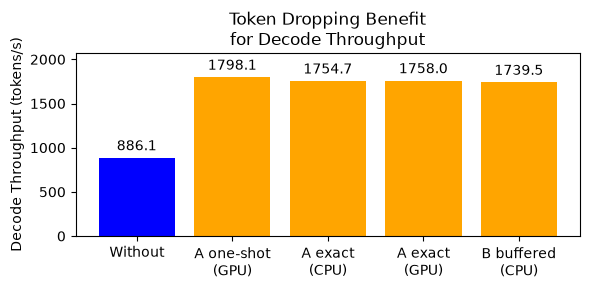

In [21]:
labels = [
    "Without",
    "A one-shot\n(GPU)",
    "A exact\n(CPU)",
    "A exact\n(GPU)",
    "B buffered\n(CPU)",
]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    oneshot_drop_data["metrics"]["results"]["output_tput"],
    cpu_exact_drop_data["metrics"]["results"]["output_tput"],
    gpu_exact_drop_data["metrics"]["results"]["output_tput"],
    buffered_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(labels, data, color=["blue"] + ["orange"] * 4)
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


## Close both contexts

In [ ]:
# Only close the context when done.
ctx.close()
qctx.close()